### Etapa 1: Entendimento do Dataset

##### Task: Carregar dataset e realizar a inspeção inicial

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
churn_clientes = pd.read_csv("../data/raw/dataset_churn_clientes.csv")
churn_clientes

,ID_Cliente,Idade,Genero,Estado,Plano,Tempo_Cliente_Meses,Mensalidade,Uso_Mensal_Horas,Quantidade_Chamados,Atrasos_Pagamento,Forma_Pagamento,Churn
0,1,58,Masculino,PE,Básico,4,73.0,9,3,1,Cartão de Crédito,Não
1,2,23,Feminino,PR,Básico,30,66.0,62,8,1,Débito Automático,Não
2,3,69,Feminino,RJ,Básico,21,72.0,16,4,1,Pix,Não
3,4,24,Feminino,RJ,Padrão,45,106.0,75,11,3,Débito Automático,Não
4,5,71,Feminino,RJ,Premium,47,250.0,114,1,0,Boleto,Não
...,...,...,...,...,...,...,...,...,...,...,...,...
2005,1274,30,Feminino,MG,Básico,67,51.0,15,1,0,Cartão de Crédito,Não
2006,939,68,Feminino,RS,NaN,61,93.0,86,0,6,Boleto,Não
2007,1732,31,Masculino,PE,Premium,47,227.0,72,12,6,Cartão de Crédito,Sim
2008,66,24,Masculino,RS,Básico,38,57.0,10,4,0,Cartão de Crédito,Não


In [40]:
churn_clientes.dtypes

ID_Cliente               int64
Idade                    int64
Genero                     str
Estado                     str
Plano                      str
Tempo_Cliente_Meses      int64
Mensalidade            float64
Uso_Mensal_Horas         int64
Quantidade_Chamados      int64
Atrasos_Pagamento        int64
Forma_Pagamento            str
Churn                      str
dtype: object

In [41]:
churn_clientes.describe()

,ID_Cliente,Idade,Tempo_Cliente_Meses,Mensalidade,Uso_Mensal_Horas,Quantidade_Chamados,Atrasos_Pagamento
count,2010.000000,2010.000000,2010.000000,1995.000000,2010.000000,2010.000000,2010.000000
mean,1001.034826,45.277114,36.427861,126.875188,62.124876,6.126866,2.954229
std,577.330122,16.900474,20.757723,60.995075,33.477180,3.826153,2.013121
min,1.000000,18.000000,1.000000,50.000000,5.000000,0.000000,0.000000
25%,501.250000,30.000000,18.000000,72.000000,32.000000,3.000000,1.000000
50%,1001.500000,45.000000,37.000000,112.000000,62.000000,6.000000,3.000000
75%,1499.750000,60.000000,54.000000,181.000000,91.750000,10.000000,5.000000
max,2000.000000,75.000000,72.000000,250.000000,120.000000,12.000000,6.000000


##### Task: Analisar estatisticas descritivas

In [42]:
media_idade = churn_clientes["Idade"].mean()
print(f"Media de idade dos clientes: {media_idade}")

Media de idade dos clientes: 45.277114427860695


In [43]:
media_mensalidade = churn_clientes["Mensalidade"].mean()
print(f"Media das mensalidades: {media_mensalidade}")

Media das mensalidades: 126.87518796992481


In [44]:
media_tempo_cliente = churn_clientes["Tempo_Cliente_Meses"].mean()
print(f"Media de meses que os clientes ficam na empresa: {media_tempo_cliente}")

Media de meses que os clientes ficam na empresa: 36.42786069651741


In [45]:
planos_distribuicao = churn_clientes.groupby("Plano").size().reset_index(name="quantidade_clientes")
planos_distribuicao

,Plano,quantidade_clientes
0,Básico,696
1,Padrão,659
2,Premium,639


In [46]:
taxa_inicio = len(churn_clientes)
taxa_sairam = (churn_clientes["Churn"] == "Sim").sum()
taxa_churn = taxa_sairam / taxa_inicio * 100
print(f"taxa inicial de churn: {taxa_churn}")

taxa inicial de churn: 29.45273631840796


### Etapa 2: Limpeza e Tratamento dos Dados

##### Task: Identificar e tratar valores ausentes

In [47]:
churn_clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 2010 entries, 0 to 2009
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_Cliente           2010 non-null   int64  
 1   Idade                2010 non-null   int64  
 2   Genero               1995 non-null   str    
 3   Estado               1995 non-null   str    
 4   Plano                1994 non-null   str    
 5   Tempo_Cliente_Meses  2010 non-null   int64  
 6   Mensalidade          1995 non-null   float64
 7   Uso_Mensal_Horas     2010 non-null   int64  
 8   Quantidade_Chamados  2010 non-null   int64  
 9   Atrasos_Pagamento    2010 non-null   int64  
 10  Forma_Pagamento      1995 non-null   str    
 11  Churn                2010 non-null   str    
dtypes: float64(1), int64(6), str(5)
memory usage: 254.2 KB


- Campos com valores nulos: Genero, Estado, Plano, Mensalidade, Forma_Pagamento

In [48]:
churn_clientes["Genero"] = churn_clientes["Genero"].fillna("Indefinido")
churn_clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 2010 entries, 0 to 2009
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_Cliente           2010 non-null   int64  
 1   Idade                2010 non-null   int64  
 2   Genero               2010 non-null   str    
 3   Estado               1995 non-null   str    
 4   Plano                1994 non-null   str    
 5   Tempo_Cliente_Meses  2010 non-null   int64  
 6   Mensalidade          1995 non-null   float64
 7   Uso_Mensal_Horas     2010 non-null   int64  
 8   Quantidade_Chamados  2010 non-null   int64  
 9   Atrasos_Pagamento    2010 non-null   int64  
 10  Forma_Pagamento      1995 non-null   str    
 11  Churn                2010 non-null   str    
dtypes: float64(1), int64(6), str(5)
memory usage: 254.1 KB


In [49]:
churn_clientes["Estado"] = churn_clientes["Estado"].fillna("ND") # ND = Nao Definido
churn_clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 2010 entries, 0 to 2009
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_Cliente           2010 non-null   int64  
 1   Idade                2010 non-null   int64  
 2   Genero               2010 non-null   str    
 3   Estado               2010 non-null   str    
 4   Plano                1994 non-null   str    
 5   Tempo_Cliente_Meses  2010 non-null   int64  
 6   Mensalidade          1995 non-null   float64
 7   Uso_Mensal_Horas     2010 non-null   int64  
 8   Quantidade_Chamados  2010 non-null   int64  
 9   Atrasos_Pagamento    2010 non-null   int64  
 10  Forma_Pagamento      1995 non-null   str    
 11  Churn                2010 non-null   str    
dtypes: float64(1), int64(6), str(5)
memory usage: 253.8 KB


In [50]:
plano_intervalo = churn_clientes.groupby("Plano")["Mensalidade"].agg(["min", "max"]).reset_index()
plano_intervalo

,Plano,min,max
0,Básico,50.0,80.0
1,Padrão,90.0,140.0
2,Premium,160.0,250.0


In [51]:
mascara = churn_clientes["Plano"].isna()

condicoes = [
    churn_clientes.loc[mascara, "Mensalidade"].between(50, 80),
    churn_clientes.loc[mascara, "Mensalidade"].between(90, 140),
    churn_clientes.loc[mascara, "Mensalidade"].between(160, 250)
]

valores = ["Básico", "Padrão", "Premium"]

churn_clientes.loc[mascara, "Plano"] = np.select(condicoes, valores, default=None)
churn_clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 2010 entries, 0 to 2009
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_Cliente           2010 non-null   int64  
 1   Idade                2010 non-null   int64  
 2   Genero               2010 non-null   str    
 3   Estado               2010 non-null   str    
 4   Plano                2010 non-null   str    
 5   Tempo_Cliente_Meses  2010 non-null   int64  
 6   Mensalidade          1995 non-null   float64
 7   Uso_Mensal_Horas     2010 non-null   int64  
 8   Quantidade_Chamados  2010 non-null   int64  
 9   Atrasos_Pagamento    2010 non-null   int64  
 10  Forma_Pagamento      1995 non-null   str    
 11  Churn                2010 non-null   str    
dtypes: float64(1), int64(6), str(5)
memory usage: 253.7 KB


In [52]:
planos_valores = {
    "Básico": 65,
    "Padrão": 115,
    "Premium": 205
}

mascara = churn_clientes["Mensalidade"].isna()

churn_clientes.loc[mascara, "Mensalidade"] = (
    churn_clientes.loc[mascara, "Plano"].map(planos_valores)
)
churn_clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 2010 entries, 0 to 2009
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_Cliente           2010 non-null   int64  
 1   Idade                2010 non-null   int64  
 2   Genero               2010 non-null   str    
 3   Estado               2010 non-null   str    
 4   Plano                2010 non-null   str    
 5   Tempo_Cliente_Meses  2010 non-null   int64  
 6   Mensalidade          2010 non-null   float64
 7   Uso_Mensal_Horas     2010 non-null   int64  
 8   Quantidade_Chamados  2010 non-null   int64  
 9   Atrasos_Pagamento    2010 non-null   int64  
 10  Forma_Pagamento      1995 non-null   str    
 11  Churn                2010 non-null   str    
dtypes: float64(1), int64(6), str(5)
memory usage: 253.7 KB


In [53]:
churn_clientes["Forma_Pagamento"] = churn_clientes["Forma_Pagamento"].fillna("Débito Automático")
churn_clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 2010 entries, 0 to 2009
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_Cliente           2010 non-null   int64  
 1   Idade                2010 non-null   int64  
 2   Genero               2010 non-null   str    
 3   Estado               2010 non-null   str    
 4   Plano                2010 non-null   str    
 5   Tempo_Cliente_Meses  2010 non-null   int64  
 6   Mensalidade          2010 non-null   float64
 7   Uso_Mensal_Horas     2010 non-null   int64  
 8   Quantidade_Chamados  2010 non-null   int64  
 9   Atrasos_Pagamento    2010 non-null   int64  
 10  Forma_Pagamento      2010 non-null   str    
 11  Churn                2010 non-null   str    
dtypes: float64(1), int64(6), str(5)
memory usage: 253.7 KB


- Tratamento de valores ausentes concluido

##### Task: Remover registros duplicados

In [54]:
duplicados = churn_clientes[churn_clientes.duplicated()]
duplicados

,ID_Cliente,Idade,Genero,Estado,Plano,Tempo_Cliente_Meses,Mensalidade,Uso_Mensal_Horas,Quantidade_Chamados,Atrasos_Pagamento,Forma_Pagamento,Churn
2000,1861,73,Masculino,RS,Padrão,38,92.0,93,3,4,Débito Automático,Sim
2001,354,41,Feminino,PE,Padrão,24,115.0,88,7,2,Boleto,Não
2002,1334,53,Masculino,SP,Básico,27,64.0,87,12,6,Cartão de Crédito,Sim
2003,906,24,Masculino,PR,Premium,38,213.0,59,2,0,Pix,Não
2004,1290,73,Masculino,RJ,Premium,17,200.0,105,9,6,Cartão de Crédito,Não
2005,1274,30,Feminino,MG,Básico,67,51.0,15,1,0,Cartão de Crédito,Não
2006,939,68,Feminino,RS,Padrão,61,93.0,86,0,6,Boleto,Não
2007,1732,31,Masculino,PE,Premium,47,227.0,72,12,6,Cartão de Crédito,Sim
2008,66,24,Masculino,RS,Básico,38,57.0,10,4,0,Cartão de Crédito,Não
2009,1324,47,Feminino,MG,Premium,35,209.0,51,12,1,Cartão de Crédito,Não


In [55]:
churn_clientes = churn_clientes.drop_duplicates()
churn_clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_Cliente           2000 non-null   int64  
 1   Idade                2000 non-null   int64  
 2   Genero               2000 non-null   str    
 3   Estado               2000 non-null   str    
 4   Plano                2000 non-null   str    
 5   Tempo_Cliente_Meses  2000 non-null   int64  
 6   Mensalidade          2000 non-null   float64
 7   Uso_Mensal_Horas     2000 non-null   int64  
 8   Quantidade_Chamados  2000 non-null   int64  
 9   Atrasos_Pagamento    2000 non-null   int64  
 10  Forma_Pagamento      2000 non-null   str    
 11  Churn                2000 non-null   str    
dtypes: float64(1), int64(6), str(5)
memory usage: 253.7 KB


- 10 registros duplicados removidos

##### Task: Padronizar dados categoricos

In [56]:
churn_clientes

,ID_Cliente,Idade,Genero,Estado,Plano,Tempo_Cliente_Meses,Mensalidade,Uso_Mensal_Horas,Quantidade_Chamados,Atrasos_Pagamento,Forma_Pagamento,Churn
0,1,58,Masculino,PE,Básico,4,73.0,9,3,1,Cartão de Crédito,Não
1,2,23,Feminino,PR,Básico,30,66.0,62,8,1,Débito Automático,Não
2,3,69,Feminino,RJ,Básico,21,72.0,16,4,1,Pix,Não
3,4,24,Feminino,RJ,Padrão,45,106.0,75,11,3,Débito Automático,Não
4,5,71,Feminino,RJ,Premium,47,250.0,114,1,0,Boleto,Não
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,38,Indefinido,MG,Padrão,33,127.0,96,4,6,Cartão de Crédito,Não
1996,1997,24,Masculino,MG,Básico,71,54.0,22,11,0,Boleto,Não
1997,1998,50,Feminino,RJ,Padrão,37,90.0,68,6,1,Débito Automático,Sim
1998,1999,62,Masculino,PR,Padrão,18,104.0,49,10,1,Pix,Não


In [57]:
colunas_nomes = ["id_cliente", "idade", "genero", "estado", "plano", "tempo_cliente_meses", "mensalidade", "uso_mensal_horas", "quantidade_chamados", "atrasos_pagamento", "forma_pagamento", "churn"]
churn_clientes.columns = colunas_nomes
churn_clientes

,id_cliente,idade,genero,estado,plano,tempo_cliente_meses,mensalidade,uso_mensal_horas,quantidade_chamados,atrasos_pagamento,forma_pagamento,churn
0,1,58,Masculino,PE,Básico,4,73.0,9,3,1,Cartão de Crédito,Não
1,2,23,Feminino,PR,Básico,30,66.0,62,8,1,Débito Automático,Não
2,3,69,Feminino,RJ,Básico,21,72.0,16,4,1,Pix,Não
3,4,24,Feminino,RJ,Padrão,45,106.0,75,11,3,Débito Automático,Não
4,5,71,Feminino,RJ,Premium,47,250.0,114,1,0,Boleto,Não
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,38,Indefinido,MG,Padrão,33,127.0,96,4,6,Cartão de Crédito,Não
1996,1997,24,Masculino,MG,Básico,71,54.0,22,11,0,Boleto,Não
1997,1998,50,Feminino,RJ,Padrão,37,90.0,68,6,1,Débito Automático,Sim
1998,1999,62,Masculino,PR,Padrão,18,104.0,49,10,1,Pix,Não


- nome das colunas padronizado

In [58]:
genero_padrao = {
    "Masculino": "m",
    "Feminino": "f",
    "Indefinido": "i"
}

churn_clientes["genero"] = churn_clientes["genero"].replace(genero_padrao)
churn_clientes

,id_cliente,idade,genero,estado,plano,tempo_cliente_meses,mensalidade,uso_mensal_horas,quantidade_chamados,atrasos_pagamento,forma_pagamento,churn
0,1,58,m,PE,Básico,4,73.0,9,3,1,Cartão de Crédito,Não
1,2,23,f,PR,Básico,30,66.0,62,8,1,Débito Automático,Não
2,3,69,f,RJ,Básico,21,72.0,16,4,1,Pix,Não
3,4,24,f,RJ,Padrão,45,106.0,75,11,3,Débito Automático,Não
4,5,71,f,RJ,Premium,47,250.0,114,1,0,Boleto,Não
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,38,i,MG,Padrão,33,127.0,96,4,6,Cartão de Crédito,Não
1996,1997,24,m,MG,Básico,71,54.0,22,11,0,Boleto,Não
1997,1998,50,f,RJ,Padrão,37,90.0,68,6,1,Débito Automático,Sim
1998,1999,62,m,PR,Padrão,18,104.0,49,10,1,Pix,Não


In [59]:
plano_padrao = {
    "Básico": "basico",
    "Padrão": "padrao",
    "Premium": "premium"
}

churn_clientes["plano"] = churn_clientes["plano"].replace(plano_padrao)
churn_clientes

,id_cliente,idade,genero,estado,plano,tempo_cliente_meses,mensalidade,uso_mensal_horas,quantidade_chamados,atrasos_pagamento,forma_pagamento,churn
0,1,58,m,PE,basico,4,73.0,9,3,1,Cartão de Crédito,Não
1,2,23,f,PR,basico,30,66.0,62,8,1,Débito Automático,Não
2,3,69,f,RJ,basico,21,72.0,16,4,1,Pix,Não
3,4,24,f,RJ,padrao,45,106.0,75,11,3,Débito Automático,Não
4,5,71,f,RJ,premium,47,250.0,114,1,0,Boleto,Não
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,38,i,MG,padrao,33,127.0,96,4,6,Cartão de Crédito,Não
1996,1997,24,m,MG,basico,71,54.0,22,11,0,Boleto,Não
1997,1998,50,f,RJ,padrao,37,90.0,68,6,1,Débito Automático,Sim
1998,1999,62,m,PR,padrao,18,104.0,49,10,1,Pix,Não


In [60]:
churn_clientes["forma_pagamento"].values

<ArrowStringArray>
['Cartão de Crédito', 'Débito Automático',               'Pix',
 'Débito Automático',            'Boleto', 'Cartão de Crédito',
 'Cartão de Crédito',               'Pix',               'Pix',
               'Pix',
 ...
 'Débito Automático', 'Débito Automático', 'Cartão de Crédito',
            'Boleto',               'Pix', 'Cartão de Crédito',
            'Boleto', 'Débito Automático',               'Pix',
 'Cartão de Crédito']
Length: 2000, dtype: str

In [61]:
fp_padrao = {
    "Cartão de Crédito": "cartao_de_credito",
    "Débito Automático": "debito_automatico",
    "Pix": "pix",
    "Boleto": "boleto"
}

churn_clientes["forma_pagamento"] = churn_clientes["forma_pagamento"].replace(fp_padrao)
churn_clientes.head(15)

,id_cliente,idade,genero,estado,plano,tempo_cliente_meses,mensalidade,uso_mensal_horas,quantidade_chamados,atrasos_pagamento,forma_pagamento,churn
0,1,58,m,PE,basico,4,73.0,9,3,1,cartao_de_credito,Não
1,2,23,f,PR,basico,30,66.0,62,8,1,debito_automatico,Não
2,3,69,f,RJ,basico,21,72.0,16,4,1,pix,Não
3,4,24,f,RJ,padrao,45,106.0,75,11,3,debito_automatico,Não
4,5,71,f,RJ,premium,47,250.0,114,1,0,boleto,Não
5,6,73,m,RS,basico,49,58.0,94,5,1,cartao_de_credito,Não
6,7,56,m,BA,premium,22,191.0,112,2,3,cartao_de_credito,Não
7,8,32,f,PR,basico,41,62.0,88,3,4,pix,Não
8,9,43,f,PE,premium,59,177.0,119,3,5,pix,Não
9,10,41,m,MG,basico,18,66.0,106,12,0,pix,Não


In [62]:
churn_padrao = {
    "Sim": "s",
    "Não": "n"
}

churn_clientes["churn"] = churn_clientes["churn"].replace(churn_padrao)
churn_clientes

,id_cliente,idade,genero,estado,plano,tempo_cliente_meses,mensalidade,uso_mensal_horas,quantidade_chamados,atrasos_pagamento,forma_pagamento,churn
0,1,58,m,PE,basico,4,73.0,9,3,1,cartao_de_credito,n
1,2,23,f,PR,basico,30,66.0,62,8,1,debito_automatico,n
2,3,69,f,RJ,basico,21,72.0,16,4,1,pix,n
3,4,24,f,RJ,padrao,45,106.0,75,11,3,debito_automatico,n
4,5,71,f,RJ,premium,47,250.0,114,1,0,boleto,n
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,38,i,MG,padrao,33,127.0,96,4,6,cartao_de_credito,n
1996,1997,24,m,MG,basico,71,54.0,22,11,0,boleto,n
1997,1998,50,f,RJ,padrao,37,90.0,68,6,1,debito_automatico,s
1998,1999,62,m,PR,padrao,18,104.0,49,10,1,pix,n


- Padronizacao dos dados categoricos realizada

### Etapa 3: Analise Exploratoria de Dados

##### Task: Analisar taxa de churn
- taxa_churn = clientes_cancelados / total_clientes

In [63]:
clientes_cancelados = (churn_clientes["churn"] == "s").sum()
total_clientes = len(churn_clientes)
print(f"total cancelados: {clientes_cancelados} | total clientes: {total_clientes}")

total cancelados: 589 | total clientes: 2000


In [64]:
taxa_churn = clientes_cancelados / total_clientes
print(f"Taxa de churn de clientes: {taxa_churn * 100}%")

Taxa de churn de clientes: 29.45%


##### Task: Analisar churn por plano
- Clientes premium cancelam menos ?
- O plano basico possui maior churn ?

In [65]:
df_churn_basico = churn_clientes[churn_clientes["plano"] == "basico"]
df_churn_padrao = churn_clientes[churn_clientes["plano"] == "padrao"]
df_churn_premium = churn_clientes[churn_clientes["plano"] == "premium"]

- Taxa de churn do plano basico

In [66]:
basico_cancelados = (df_churn_basico["churn"] == "s").sum()
total_basicos = len(df_churn_basico)
taxa_churn_basico = basico_cancelados / total_basicos
taxa_churn_basico

np.float64(0.351506456241033)

- Taxa de churn do plano padrao

In [67]:
padrao_cancelados = (df_churn_padrao["churn"] == "s").sum()
total_padrao = len(df_churn_padrao)
taxa_churn_padrao = padrao_cancelados / total_padrao
taxa_churn_padrao

np.float64(0.26586102719033233)

- Taxa de churn do plano premium

In [68]:
premium_cancelados = (df_churn_premium["churn"] == "s").sum()
total_premium = len(df_churn_premium)
taxa_churn_premium = premium_cancelados / total_premium
taxa_churn_premium

np.float64(0.2620904836193448)

In [69]:
print("Churn por plano")
print(f"Basico: {taxa_churn_basico * 100:.2f}%")
print(f"Padrao: {taxa_churn_padrao * 100:.2f}%")
print(f"Premium: {taxa_churn_premium * 100:.2f}%")

Churn por plano
Basico: 35.15%
Padrao: 26.59%
Premium: 26.21%


- Clientes do plano premium costumam cancelar menos que os clientes dos outros planos
- O plano com a maior taxa de churn em relacao ao numero de clientes de tal plano, e o Basico

##### Relacao entre tempo de cliente e churn

In [70]:
clientes_ate_um_ano = churn_clientes[churn_clientes["tempo_cliente_meses"] <= 12]
clientes_ate_um_ano

,id_cliente,idade,genero,estado,plano,tempo_cliente_meses,mensalidade,uso_mensal_horas,quantidade_chamados,atrasos_pagamento,forma_pagamento,churn
0,1,58,m,PE,basico,4,73.0,9,3,1,cartao_de_credito,n
16,17,22,m,PR,padrao,3,125.0,13,9,1,cartao_de_credito,s
17,18,73,m,CE,padrao,10,105.0,36,10,3,pix,s
20,21,47,m,RJ,basico,10,64.0,101,0,5,boleto,n
50,51,45,m,CE,padrao,4,111.0,21,10,6,cartao_de_credito,s
...,...,...,...,...,...,...,...,...,...,...,...,...
1987,1988,18,f,CE,basico,3,50.0,35,6,1,cartao_de_credito,n
1988,1989,57,m,RJ,basico,1,66.0,37,12,6,cartao_de_credito,s
1989,1990,43,m,PR,basico,3,68.0,22,9,6,pix,n
1991,1992,37,m,SP,premium,11,214.0,7,7,2,debito_automatico,n


In [71]:
taxa_churn_clientes_ate_um_ano = (clientes_ate_um_ano["churn"] == "s").sum() / total_clientes
print(f"Taxa de churn de clientes que ficaram ate 1 ano: {taxa_churn_clientes_ate_um_ano * 100:.2f}%")

Taxa de churn de clientes que ficaram ate 1 ano: 7.65%


In [72]:
churn_clientes["tempo_cliente_meses"].max()

np.int64(72)

- O cliente que ficou mais tempo na empresa tem 72 meses de empresa

In [73]:
clientes_antigos = churn_clientes[churn_clientes["tempo_cliente_meses"] >= 60]
clientes_antigos

,id_cliente,idade,genero,estado,plano,tempo_cliente_meses,mensalidade,uso_mensal_horas,quantidade_chamados,atrasos_pagamento,forma_pagamento,churn
14,15,70,m,RS,basico,69,74.0,72,10,3,pix,n
21,22,28,f,RS,padrao,63,103.0,105,0,1,pix,n
22,23,36,m,SP,padrao,72,135.0,100,2,1,debito_automatico,n
23,24,21,m,RJ,basico,62,65.0,81,0,4,cartao_de_credito,s
34,35,42,m,PR,basico,61,57.0,8,5,2,boleto,n
...,...,...,...,...,...,...,...,...,...,...,...,...
1984,1985,32,m,MG,padrao,70,122.0,20,4,3,boleto,n
1986,1987,30,m,PR,premium,63,178.0,102,0,2,boleto,n
1990,1991,30,m,PE,padrao,69,139.0,6,11,3,debito_automatico,n
1993,1994,38,f,MG,basico,72,70.0,7,4,2,boleto,n


In [74]:
taxa_churn_clientes_antigos = (clientes_antigos["churn"] == "s").sum() / total_clientes
print(f"Taxa de churn de clientes antigos: {taxa_churn_clientes_antigos * 100:.2f}%")

Taxa de churn de clientes antigos: 4.20%


- A retencao de clientes com mais de 5 anos de empresa e maior do que aqueles com menos de 1 ano de empresa

##### Task: Analisar comportamento de uso

In [75]:
df_clientes_ativos = churn_clientes[churn_clientes["churn"] == "n"]
df_clientes_cancelados = churn_clientes[churn_clientes["churn"] == "s"]

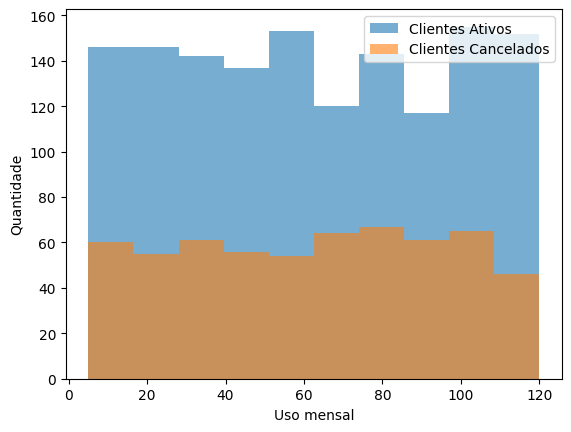

In [76]:
plt.hist(df_clientes_ativos["uso_mensal_horas"], alpha=0.6, label="Clientes Ativos")
plt.hist(df_clientes_cancelados["uso_mensal_horas"], alpha=0.6, label="Clientes Cancelados")

plt.xlabel("Uso mensal")
plt.ylabel("Quantidade")
plt.legend()
plt.show()

In [78]:
churn_clientes["churn_num"] = churn_clientes["churn"].map({
    "n": 0,
    "s": 1
})

churn_clientes

,id_cliente,idade,genero,estado,plano,tempo_cliente_meses,mensalidade,uso_mensal_horas,quantidade_chamados,atrasos_pagamento,forma_pagamento,churn,churn_num
0,1,58,m,PE,basico,4,73.0,9,3,1,cartao_de_credito,n,0
1,2,23,f,PR,basico,30,66.0,62,8,1,debito_automatico,n,0
2,3,69,f,RJ,basico,21,72.0,16,4,1,pix,n,0
3,4,24,f,RJ,padrao,45,106.0,75,11,3,debito_automatico,n,0
4,5,71,f,RJ,premium,47,250.0,114,1,0,boleto,n,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,38,i,MG,padrao,33,127.0,96,4,6,cartao_de_credito,n,0
1996,1997,24,m,MG,basico,71,54.0,22,11,0,boleto,n,0
1997,1998,50,f,RJ,padrao,37,90.0,68,6,1,debito_automatico,s,1
1998,1999,62,m,PR,padrao,18,104.0,49,10,1,pix,n,0


In [81]:
colunas = [
    "uso_mensal_horas",
    "quantidade_chamados",
    "atrasos_pagamento",
    "churn_num"
]

correlacao = churn_clientes[colunas].corr()
correlacao

,uso_mensal_horas,quantidade_chamados,atrasos_pagamento,churn_num
uso_mensal_horas,1.000000,-0.053830,-0.026066,0.000217
quantidade_chamados,-0.053830,1.000000,-0.001644,0.208263
atrasos_pagamento,-0.026066,-0.001644,1.000000,0.141624
churn_num,0.000217,0.208263,0.141624,1.000000


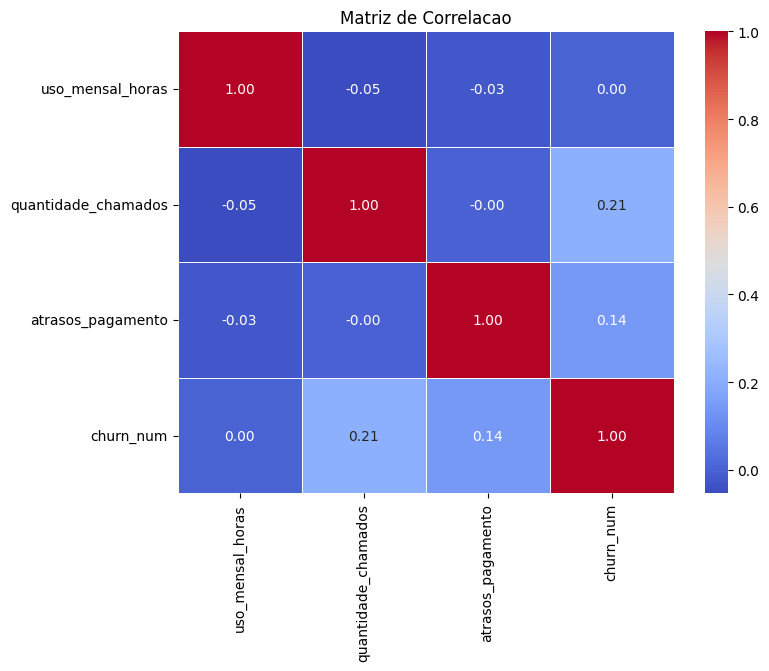

In [84]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de Correlacao")
plt.show()

- Baseado no valor da correlacao de Pearson entre as variaveis, e possivel concluir que o uso mensal, quantidade de chamados e atrasos no pagamento nao influenciam de forma significativa no cancelamento ou permanencia dos clientes na empresa